# Laboratório: Distribuições Amostrais, LLN e TLC

## Organização da atividade

- Formem grupos de 2 a 4 alunos.
- Tempo sugerido: 30 a 40 minutos.
- Entreguem um único notebook Jupyter por grupo, com os gráficos, a tabela e respostas breves às perguntas de interpretação.
- Usem uma semente fixa para que os resultados possam ser reproduzidos.

## Objetivo

Investigar, por simulação, o comportamento da média amostral quando a população de origem é assimétrica. Ao final, o grupo deve distinguir:

- as propriedades exatas da distribuição amostral da média;
- a concentração prevista pela Lei dos Grandes Números (LLN);
- a aproximação da forma normal fornecida pelo Teorema do Limite Central (TLC);
- o papel do erro padrão na regra empírica aplicada a médias amostrais.

## Situação-problema

Considere uma população modelada por uma distribuição Gamma com parâmetros:

$$
X \sim \operatorname{Gamma}(\text{shape}=2,\ \text{scale}=2).
$$

Essa população é assimétrica à direita. Seus parâmetros são:

$$
\mu = \operatorname{E}[X] = 4
\qquad\text{e}\qquad
\sigma^2 = \operatorname{Var}(X) = 8.
$$

Para cada tamanho amostral $n \in \{5, 30, 100\}$, gere $R=10\,000$ amostras i.i.d. e calcule uma média amostral para cada uma delas. Denote por `medias_n` o vetor das $R$ médias obtidas para um dado valor de $n$.

### Dicas iniciais de Python

- Crie um gerador reprodutível com `rng = np.random.default_rng(20260825)`.
- Gere todas as amostras de uma vez com `rng.gamma(shape=2, scale=2, size=(R, n))`.
- Calcule as médias de cada linha com `amostras.mean(axis=1)`.
- Guarde os resultados em um dicionário, por exemplo `medias_por_n[n] = medias_n`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260825)

# parâmetros da população normal
media_populacao = 4
variancia_populacao = 8
amostra_tamanho1 = 5
amostra_tamanho2 = 30
amostra_tamanho3 = 100
num_amostras = 10_000

amostras = rng.gamma(shape=2, scale=2, size=(num_amostras, amostra_tamanho1))
medias_n1 = amostras.mean(axis=1)
medias_por_n = {}
medias_por_n[amostra_tamanho1] = medias_n1

amostras = rng.gamma(shape=2, scale=2, size=(num_amostras, amostra_tamanho2))
medias_n2 = amostras.mean(axis=1)
medias_por_n[amostra_tamanho2] = medias_n2

amostras = rng.gamma(shape=2, scale=2, size=(num_amostras, amostra_tamanho3))
medias_n3 = amostras.mean(axis=1)
medias_por_n[amostra_tamanho3] = medias_n3

---

## Parte 1. Média e variância da distribuição amostral

Para cada valor de $n$, construa uma tabela com:

- a média empírica de `medias_n`;
- a variância empírica de `medias_n`;
- o valor teórico de $\operatorname{E}[\overline{X}_n]$;
- o valor teórico de $\operatorname{Var}(\overline{X}_n)$.

Em seguida, responda:

1. As médias empíricas estão próximas de $\mu=4$? O que isso ilustra?
2. Compare as variâncias empíricas com $8/n$. O que acontece com a variabilidade de $\overline{X}_n$ quando $n$ aumenta?
3. As fórmulas $\operatorname{E}[\overline{X}_n]=\mu$ e $\operatorname{Var}(\overline{X}_n)=\sigma^2/n$ são fornecidas pelo TLC ou são propriedades exatas sob observações i.i.d.?

### Dicas de Python

- Use `medias_n.mean()` para a média empírica.
- Use `medias_n.var()` para a variância empírica. Como as $R$ médias representam a distribuição simulada, use a convenção padrão `ddof=0` para compará-la a $8/n$.
- Calcule o valor teórico com `8 / n`.
- Uma tabela simples pode ser feita com uma lista de dicionários e `pandas.DataFrame(...)`.

In [4]:
import pandas as pd

# Checagem: E[X̄] = média da população e Var(X̄) = variância da população / n.
print(f"Média empírica de X̄ (n={amostra_tamanho1}): {medias_n1.mean():.4f}")
print(f"Variância empírica de X̄ (n={amostra_tamanho1}): {medias_n1.var(ddof=0):.4f}")
print(f"Média teórica de X̄: {media_populacao:.4f}")
print(f"Variância teórica de X̄ (n={amostra_tamanho1}): {variancia_populacao/amostra_tamanho1:.4f}")

dados_tabela = [] # Inicializa como uma lista vazia
for n, medias_n in medias_por_n.items():
    media_empirica = medias_n.mean()
    variancia_empirica = medias_n.var(ddof=0)
    media_teorica = media_populacao
    variancia_teorica = variancia_populacao / n
    dados_tabela.append({ # Adiciona um dicionário à lista em cada iteração
        'n': n,
        'Média Empírica': f"{media_empirica:.4f}",
        'Variância Empírica': f"{variancia_empirica:.4f}",
        'Média Teórica': f"{media_teorica:.4f}",
        'Variância Teórica': f"{variancia_teorica:.4f}"
    })

tabela_comparacao = pd.DataFrame(dados_tabela) # Cria o DataFrame após o loop
print("\nComparação de Média e Variância:")
print(tabela_comparacao.to_markdown(index=False))

Média empírica de X̄ (n=5): 3.9895
Variância empírica de X̄ (n=5): 1.5585
Média teórica de X̄: 4.0000
Variância teórica de X̄ (n=5): 1.6000

Comparação de Média e Variância:
|   n |   Média Empírica |   Variância Empírica |   Média Teórica |   Variância Teórica |
|----:|-----------------:|---------------------:|----------------:|--------------------:|
|   5 |           3.9895 |               1.5585 |               4 |              1.6    |
|  30 |           4.001  |               0.2632 |               4 |              0.2667 |
| 100 |           4.0002 |               0.0803 |               4 |              0.08   |


##Respostas da Parte 1:

1. Sim, as médias empíricas estão extremamente próximas, apesar de não serem iguais. Além disso, pode-se perceber que, conforme o tamanho da amostra aumenta, mais próximo o valor da média empírica está da média teórica. Isto descreve que a distribuição amostral da média amostral pode ser utilizada como forma de aproximarmos o parâmetro populacional o qual, muitas das vezes, pode ser desconhecido.

2. Quanto maior o tamanho da amostra, menor a variância da média amostral. Portanto, quanto maior o tamanho das amostras que estivermos analisando, mais próximos estarão os valores da média amostral em relação à própria média populacional.

3. As fórmulas são propriedades exatas derivadas de observações i.i.d., sendo validas para amostras de qualquer tamanho. Em paralelo, temos que o Teorema do Limite Central (TLC) não fornece essas fórmulas diretamente, mas sim garante que a forma da distribuição da média amostral sempre se aproximará de uma Distribuição Normal à medida que o tamanho das amostras analisadas cresce.

---

## Parte 2. Forma da distribuição e TLC

Faça três histogramas, um para cada valor de $n$, mostrando a distribuição empírica de `medias_n`. Sobreponha, em cada gráfico, a densidade da normal com média $4$ e variância $8/n$.

Em seguida, responda:

4. Em qual histograma a aproximação normal parece menos adequada? Relacione sua resposta à assimetria da população de origem.
5. Como mudam a largura e a forma dos histogramas quando $n$ cresce?
6. Explique por que esses gráficos não dizem que a população Gamma “se tornou normal”.

### Dicas de Python

- Use `plt.hist(medias_n, bins=..., density=True, alpha=...)`.
- Para a curva normal, use `from scipy.stats import norm` e `norm.pdf(x, loc=4, scale=np.sqrt(8/n))`.
- Crie os valores de `x` com `np.linspace(...)`. Uma faixa útil é de `4 - 4*np.sqrt(8/n)` até `4 + 4*np.sqrt(8/n)`.
- Para organizar os gráficos, use `fig, axes = plt.subplots(1, 3, figsize=(...))` e selecione cada eixo com `axes[i]`.



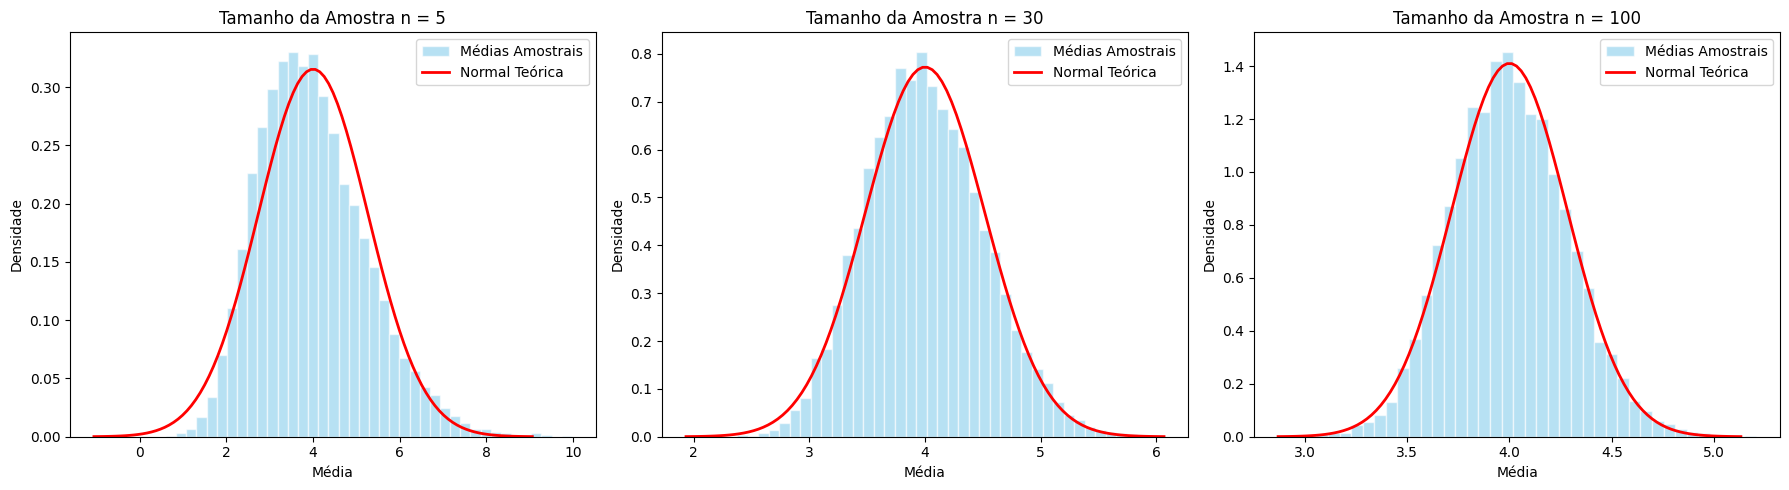

In [5]:
from scipy.stats import norm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (n, medias_n) in zip(axes, medias_por_n.items()):
    # Plot do histograma
    ax.hist(medias_n, bins=40, density=True, alpha=0.6, color='skyblue', edgecolor='white', label='Médias Amostrais')

    # Parâmetros da Normal teórica
    mu = 4
    sigma_n = np.sqrt(8 / n)

    # Gerar curva Normal
    x = np.linspace(mu - 4*sigma_n, mu + 4*sigma_n, 100)
    y = norm.pdf(x, loc=mu, scale=sigma_n)

    ax.plot(x, y, color='red', lw=2, label='Normal Teórica')
    ax.set_title(f'Tamanho da Amostra n = {n}')
    ax.set_xlabel('Média')
    ax.set_ylabel('Densidade')
    ax.legend()

plt.tight_layout()
plt.show()

##Respostas da Parte 2:

1. A aproximação normal menos adequada é a que possui um menor tamanho de amostra, sendo no caso a de tamanho igual a 5. Podemos perceber que, conforme vamos aumentando o tamanho das amostras analisadas, a distribuição normal formada pela distribuição amostral se aproxima cada vez mais da distribuição normal descrita pela população estudada.

2. Conforme o tamanho das amostras cresce, não só o valor dos histogramas se concentram cada vez mais próximos da média populacional, a qual descreve o comportamento da distribuição normal neste caso, mas também reduzem sua faixa de valores possíveis, uma vez que o crescimento do tamanho das amostras também contribuirá para uma redução da variância dentro desta distribuição amostral.

3. Apesar das distribuições amostrais acima ilustrarem distribuições muito próximas do que seriam distribuições normais, isto não diz nada sobre o comportamento da distribuição da população em si. De acordo com o Teorema do Limite Central, independente da distribuição que a população assumir, conforme aumentamos o tamanho das amostras que estamos analisando, mais próxima a curva formada pela distribuição amostral estará de curva formada por uma distribuição normal.

---

## Parte 3. Convergência em probabilidade e LLN

Fixe $\varepsilon=0{,}25$. Para cada valor de $n$, estime por simulação:

$$
\Pr\left(\left|\overline{X}_n-4\right|<0{,}25\right).
$$

Em seguida, responda:

7. Como essa probabilidade se comporta nos três tamanhos amostrais?
8. Explique o resultado usando a expressão “converge em probabilidade”.
9. A LLN garante que a probabilidade estimada será estritamente maior em todo valor sucessivo de $n$ em uma simulação finita? Justifique brevemente.

### Dicas de Python

- Calcule os desvios com `np.abs(medias_n - mu)`.
- O evento de interesse é `np.abs(medias_n - mu) < epsilon`.
- Como `True` vale 1 e `False` vale 0 em cálculos numéricos, a probabilidade simulada é `evento.mean()` ou `np.mean(evento)`.
- Um gráfico simples pode usar `plt.plot(valores_n, probabilidades, marker='o')` e `plt.ylim(0, 1.05)`.


Probabilidade estimada Pr(|X̄_n - 4| < 0.25):
n =   5: 0.1589
n =  30: 0.3679
n = 100: 0.6225


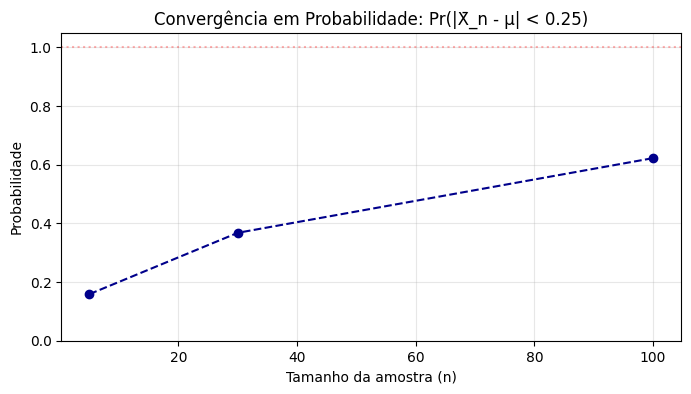

In [11]:
epsilon = 0.25
mu = 4
valores_n = []
probabilidades = []

print(f"Probabilidade estimada Pr(|X̄_n - {mu}| < {epsilon}):")

for n, medias_n in medias_por_n.items():
    # Calcula o evento: |X̄_n - μ| < ε
    desvios = np.abs(medias_n - mu)
    evento = desvios < epsilon
    prob = np.mean(evento)

    valores_n.append(n)
    probabilidades.append(prob)
    print(f"n = {n:3d}: {prob:.4f}")

# Gráfico da convergência
plt.figure(figsize=(8, 4))
plt.plot(valores_n, probabilidades, marker='o', linestyle='--', color='darkblue')
plt.axhline(1, color='red', alpha=0.3, linestyle=':')
plt.xlabel("Tamanho da amostra (n)")
plt.ylabel("Probabilidade")
plt.title(f"Convergência em Probabilidade: Pr(|X̄_n - μ| < {epsilon})")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

##Respostas da Parte 3:

1. Conforme os tamanhos amostrais vão aumentando, esta probabilidade vai aumentando também. Isto tende a acontecer pois a distância entre a média amostral e a média da população diminui à medida que o tamanho das amostras analisadas aumenta.

2. O resultado mostra que, conforme o tamanho das amostras tende para infinito, a média amostral converge em probabilidade para a média populacional. Isto quer dizer que, quanto maior for o tamanho da amostra que estivermos analisando, mais próximo o valor da esperança da média amostral estará da própria média populacional. E, em vista disso, a expressão probabilística descrita acima acaba tendendo a 1, uma vez que todas as ocorrências da média em uma amostra tenderão a ser equivalentes ou iguais à média populacional.

3. Não. A Lei dos Grandes Números é um teorema assintótico, ou seja, ela garante o comportamento no limite, quando $n$ tende ao infinito. Portanto, ela não garante que a probabilidade cresça obrigatoriamente a cada passo em simulações finitas. Como a simulação computacional utiliza números pseudoaleatórios e gera um número finito de amostras, a aleatoriedade pode fazer com que, pontualmente, um tamanho de amostra um pouco maior acabe gerando uma probabilidade estimada levemente menor do que um outro tamanho anterior, antes de finalmente estabilizar em 1. O importante é entendermos o comportamento quando $n$ está se aproximando de infinito e não ao redor de sua trajetória, logo, o que levamos de mais importante é que a probabilidade final tenderá a 1, independente de qual caminho de amostras percorremos para chegar neste resultado.

---

## Parte 4. Regra empírica e erro padrão

Considere apenas o caso $n=100$. Calcule o erro padrão teórico:

$$
\sigma_{\overline{X}_{100}} = \frac{\sigma}{\sqrt{100}}.
$$

Em seguida, estime a proporção de médias simuladas que pertence ao intervalo:

$$
\mu \pm 2\sigma_{\overline{X}_{100}}.
$$

Por fim, escolha uma das médias simuladas e calcule seu escore-z:

$$
z=\frac{\overline{x}-\mu}{\sigma/\sqrt{n}}.
$$



Responda:

10. Qual é o erro padrão para $n=100$? Qual é a faixa aproximada de 95% para as médias amostrais?
11. A proporção simulada ficou próxima de 95%? Por que esse resultado é uma aproximação neste problema?
12. Interprete o escore-z calculado: quantos erros padrão a média observada está distante de $\mu$?

### Dicas de Python

- O desvio-padrão populacional é `sigma = np.sqrt(8)`.
- Calcule o erro padrão com `erro_padrao = sigma / np.sqrt(100)`.
- Defina os limites com `limite_inferior = mu - 2 * erro_padrao` e `limite_superior = mu + 2 * erro_padrao`.
- A proporção simulada pode ser obtida com `np.mean((medias_100 >= limite_inferior) & (medias_100 <= limite_superior))`.
- Escolha, por exemplo, `xbar_observada = medias_100[0]` e calcule `z = (xbar_observada - mu) / erro_padrao`.

---

## Síntese final

Em um único parágrafo, expliquem a diferença entre as três afirmações abaixo:

1. $\operatorname{E}[\overline{X}_n]=\mu$ e $\operatorname{Var}(\overline{X}_n)=\sigma^2/n$;
2. $\overline{X}_n \xrightarrow{P} \mu$;
3. $\overline{X}_n \approx \mathcal{N}(\mu,\sigma^2/n)$ para $n$ grande.

O parágrafo deve identificar quais afirmações são exatas, qual descreve concentração em torno do alvo e qual descreve uma aproximação de forma.


In [7]:
# 1. Cálculo do Erro Padrão para n = 100
sigma = np.sqrt(8)
n_alvo = 100
erro_padrao = sigma / np.sqrt(n_alvo)

# 2. Intervalo de 2 erros padrões
limite_inf = mu - 2 * erro_padrao
limite_sup = mu + 2 * erro_padrao

# 3. Proporção empírica dentro do intervalo
medias_100 = medias_por_n[n_alvo]
proporcao = np.mean((medias_100 >= limite_inf) & (medias_100 <= limite_sup))

# 4. Escore-z para a primeira média da amostra simulada
xbar_obs = medias_100[0]
z = (xbar_obs - mu) / erro_padrao

print(f"--- Resultados para n = {n_alvo} ---")
print(f"Erro Padrão (σ_X̄): {erro_padrao:.4f}")
print(f"Intervalo μ ± 2σ_X̄: [{limite_inf:.4f}, {limite_sup:.4f}]")
print(f"Proporção simulada no intervalo: {proporcao:.4f} (Esperado ~0.9545)")
print(f"Média observada (1ª): {xbar_obs:.4f}")
print(f"Escore-z calculado: {z:.4f}")

--- Resultados para n = 100 ---
Erro Padrão (σ_X̄): 0.2828
Intervalo μ ± 2σ_X̄: [3.4343, 4.5657]
Proporção simulada no intervalo: 0.9556 (Esperado ~0.9545)
Média observada (1ª): 3.5874
Escore-z calculado: -1.4587


##Respostas da Parte 4:

1. O erro padrão para $n=100$ é, aproximadamente, igual a 0,2828. A faixa de 95% encontrada é aproximadamente equivalente ao intervalo $[3,4343; 4,5657]$.

2. Sim, a proporção simulada ficou muito próxima dos 95,45% teóricos da distribuição Normal. Esse resultado é uma aproximação porque a população original possui uma distribuição do tipo Gamma, mas, pelo Teorema do Limite Central, a distribuição da média amostral para $n=100$ já é suficientemente próxima de uma distribuição Normal.

3. O escore-z calculado foi de aproximadamente $-1,4587$. Isso significa que essa média observada específica está a 1,4587 erros padrões abaixo da média populacional $\mu=4$.

## Síntese final

As três afirmações descrevem visões distintas do comportamento da média amostral, apesar de todas serem bem próximas. A afirmação 1 expressa propriedades exatas  sobre a média amostral e também sobre a variância amostral: a média amostral é um estimador não viesado da média populacional e sua variabilidade encolhe de maneira inversamente proporcional a $n$, independente da distribuição original da população. A afirmação 2, referente à Lei dos Grandes Números, descreve como amostras grandes o suficiente fazem com que o valor da média amostral tenda ao valor da média populacional. Por fim, a afirmação 3, referente ao Teorema do Limite Central, indica que, embora a população possa ter uma distribuição totalmente assimétrica, a distribuição da média amostral assume a forma de sino (comportamento comum da distribuição normal) conforme o tamanho das amostras analisadas cresce. Isto permite que utilízemos de regras empíricas e cálculos de probabilidade baseados justamente no comportamento da distribuição normal para conseguir inferir características sobre a população que estivermos analisando.